In [6]:
# Numerical operations
import numpy as np

# Data handling
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# TensorFlow / Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [7]:
from sklearn.datasets import fetch_openml

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Convert into dataframe
data = boston.frame

# Show first 5 rows
data.head()

c:\100Xomm\JupyterNotebook-VS Code\Linear Regression Model Training\tfenv\lib\site-packages\sklearn\datasets\_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/531. Retrying...
  warn(
c:\100Xomm\JupyterNotebook-VS Code\Linear Regression Model Training\tfenv\lib\site-packages\sklearn\datasets\_openml.py:109: UserWarning: A network error occurred while downloading https://api.openml.org/api/v1/json/data/features/531. Retrying...
  warn(


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2


In [9]:
# Shape of dataset
print(data.shape)

# Column names
print(data.columns)

# Dataset info
data.info()

(506, 14)
Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   CRIM     506 non-null    float64 
 1   ZN       506 non-null    float64 
 2   INDUS    506 non-null    float64 
 3   CHAS     506 non-null    category
 4   NOX      506 non-null    float64 
 5   RM       506 non-null    float64 
 6   AGE      506 non-null    float64 
 7   DIS      506 non-null    float64 
 8   RAD      506 non-null    category
 9   TAX      506 non-null    float64 
 10  PTRATIO  506 non-null    float64 
 11  B        506 non-null    float64 
 12  LSTAT    506 non-null    float64 
 13  MEDV     506 non-null    float64 
dtypes: category(2), float64(12)
memory usage: 49.0 KB


In [10]:
data.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [11]:
data.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000,50.000000


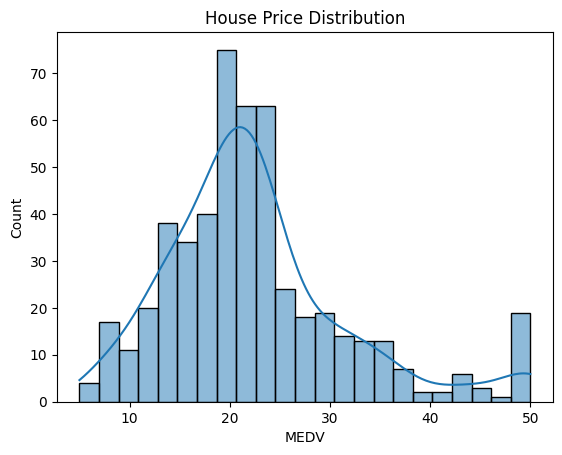

In [12]:
sns.histplot(data['MEDV'], kde=True)

plt.title("House Price Distribution")
plt.show()

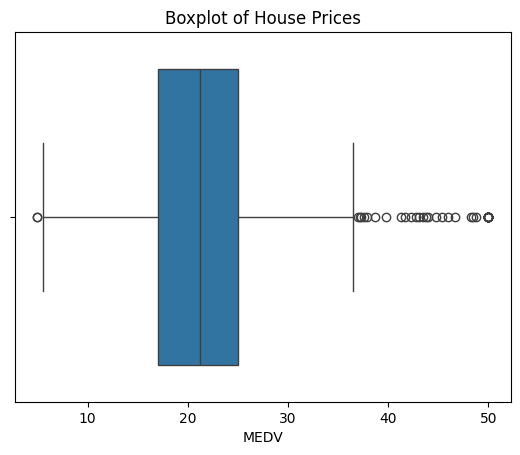

In [13]:
sns.boxplot(x=data['MEDV'])

plt.title("Boxplot of House Prices")
plt.show()

In [14]:
correlation = data.corr(numeric_only=True)

correlation['MEDV'].sort_values(ascending=False)

MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
AGE       -0.376955
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

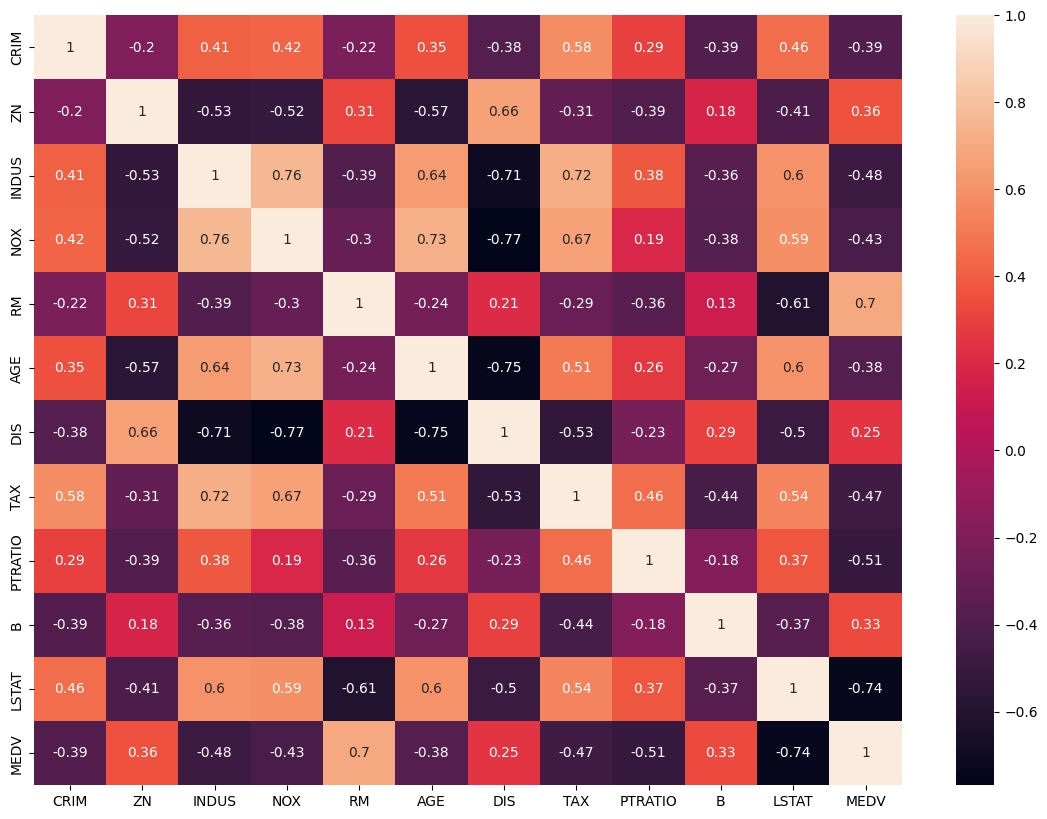

In [15]:
plt.figure(figsize=(14,10))

sns.heatmap(correlation, annot=True)

plt.show()

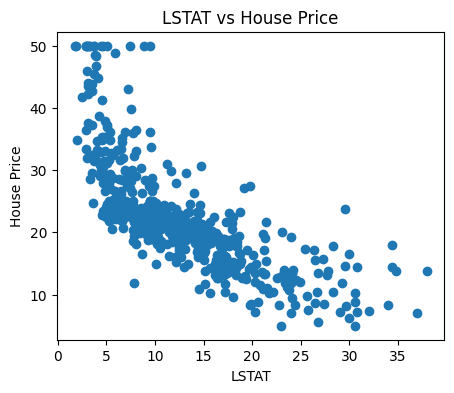

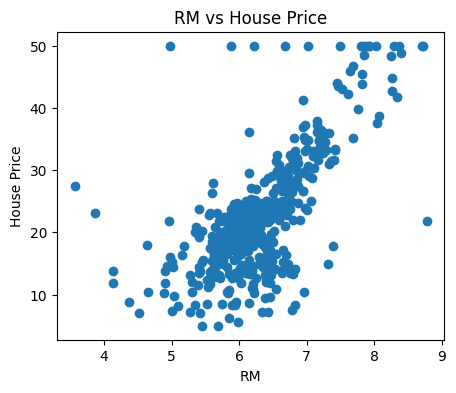

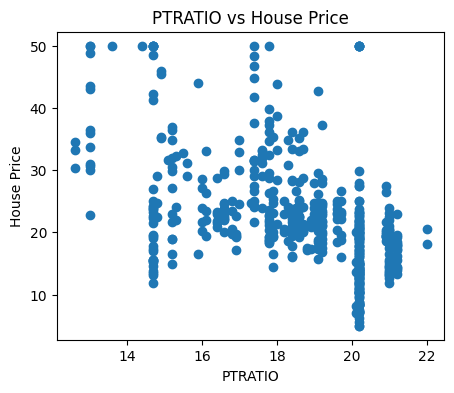

In [16]:
features = ['LSTAT', 'RM', 'PTRATIO']

for col in features:
    plt.figure(figsize=(5,4))
    
    plt.scatter(data[col], data['MEDV'])
    
    plt.xlabel(col)
    plt.ylabel("House Price")
    
    plt.title(f"{col} vs House Price")
    
    plt.show()

In [17]:
X = data.drop('MEDV', axis=1)

y = data['MEDV']

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [20]:
lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_pred_lr = lr_model.predict(X_test)

In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

r2 = r2_score(y_test, y_pred_lr)

print("RMSE:", rmse)

print("R2 Score:", r2)

RMSE: 4.928602182665336
R2 Score: 0.668759493535632


In [23]:
model = Sequential()

model.add(Dense(128, activation='relu', input_shape=(13,)))

model.add(Dense(64, activation='relu'))

model.add(Dense(32, activation='relu'))

model.add(Dense(16, activation='relu'))

model.add(Dense(1))

c:\100Xomm\JupyterNotebook-VS Code\Linear Regression Model Training\tfenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.compile(
    optimizer='adam',
    loss='mean_squared_error',
    metrics=['mae']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    validation_split=0.05
)

Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 595.1665 - mae: 22.4958 - val_loss: 492.9774 - val_mae: 20.6884
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 535.9114 - mae: 21.1124 - val_loss: 410.7162 - val_mae: 18.6360
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 403.5539 - mae: 17.8133 - val_loss: 250.1128 - val_mae: 13.8218
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 197.7775 - mae: 11.4718 - val_loss: 76.0182 - val_mae: 5.9602
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 88.5591 - mae: 7.3856 - val_loss: 62.9620 - val_mae: 5.1823
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 51.3097 - mae: 5.4383 - val_loss: 60.8089 - val_mae: 4.9151
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 33.8612 - mae: 4.2879 - val_loss: 60.6643 - val_mae: 4.9955
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 26.5580 - mae: 3.8287 - val_loss: 57.7696 - val_mae: 5.0127
Epoch 9/100
12/12 ━━━━━━━━━━━━

In [26]:
mse_nn, mae_nn = model.evaluate(X_test, y_test)

print("MSE:", mse_nn)

print("MAE:", mae_nn)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.9348 - mae: 2.0417 
MSE: 9.934828758239746
MAE: 2.0416736602783203


In [27]:
prediction = model.predict(X_test[:5])

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
[[27.811758]
 [34.04352 ]
 [15.791642]
 [24.262331]
 [16.148455]]


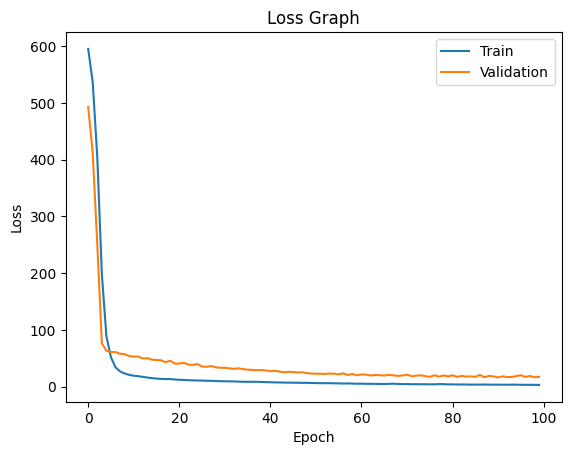

In [28]:
plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.legend(['Train', 'Validation'])

plt.title("Loss Graph")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.show()